# LLM Tutorial

In [203]:
# Imports
import json
import numpy as np
import pandas as pd
import torch
from IPython.display import display_html
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

## My Healthcare Issue

- Issue: Predict prediabetes based on patient info (demographics), observations, and conditions
    - Binary classification problem
- Methods:
    - In-Context Learning
    - Few Shot Learning
    - Chain-of-Thought
    - Tree of Thought

## Set Up Language Model

In [204]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model from HuggingFace
checkpoint = "HuggingFaceTB/SmolLM2-360M-Instruct"  # Smaller model for demo
# checkpoint = "HuggingFaceTB/SmolLM2-1.7B-Instruct"  # Larger model for if you have enough resources

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForCausalLM.from_pretrained(checkpoint).to(device)

## Load Data
Medical Dataset Used: 
- Publicly available synthesized data (7 MB of data with 100 patients)
    - Tables used (3):
        - patients
        - observations
        - conditions
        - careplans
1. Download ***Latest Version of Synthea:** 100 Sample Synthetic Patient Records, CSV: 7 MB* from https://synthea.mitre.org/downloads
2. Save and unzip your downloaded `synthea_sample_data_csv_latest.zip` to a data path you can access via this notebook.

In [205]:
# Set your data path:
DATA_PATH = '../../data/llm/synthea_sample_data_csv_latest/'

# Helper function for data loading and previewing
def load_and_preview_data(dfs, csv_filename):
    df = pd.read_csv(DATA_PATH + csv_filename + '.csv')
    print(csv_filename.capitalize(), 'data loaded. Shape:', df.shape)
    display_html(df.head())
    dfs[csv_filename] = df
    return dfs

# Specify desired tables
dfs_to_load = [
    'patients',
    'observations',
    'conditions',
    'careplans',
]
dfs = {}  # Store dataframes here
# Load the dataframes
for df in dfs_to_load:
    dfs = load_and_preview_data(dfs, df)

Patients data loaded. Shape: (106, 28)


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,30a6452c-4297-a1ac-977a-6a23237c7b46,1994-02-06,NaN,999-52-8591,S99996852,X47758697X,Mr.,Joshua658,Alvin56,Kunde533,...,Braintree,Massachusetts,Norfolk County,25021.0,2184,42.211142,-71.045802,56904.96,18019.99,100511
1,34a4dcc4-35fb-6ad5-ab98-be285c586a4f,1968-08-06,2009-12-11,999-75-3953,S99993577,X28173268X,Mr.,Bennie663,NaN,Ebert178,...,Braintree,Massachusetts,Norfolk County,25021.0,2184,42.255420,-70.971016,124024.12,1075.06,49737
2,7179458e-d6e3-c723-2530-d4acfe1c2668,2008-12-21,NaN,999-70-1925,NaN,NaN,NaN,Hunter736,Mckinley734,Gerlach374,...,Mattapoisett,Massachusetts,Plymouth County,NaN,0,41.648292,-70.850619,45645.06,6154.94,133816
3,37c177ea-4398-fb7a-29fa-70eb3d673876,1994-01-27,NaN,999-27-9779,S99995100,X83694889X,Mrs.,Carlyn477,Florencia449,Williamson769,...,Wareham,Massachusetts,Plymouth County,NaN,0,41.789096,-70.711616,12895.15,659951.61,17382
4,0fef2411-21f0-a269-82fb-c42b55471405,2019-07-27,NaN,999-50-8977,NaN,NaN,NaN,Robin66,Jeramy610,Gleichner915,...,Groveland,Massachusetts,Essex County,NaN,0,42.734183,-70.976410,18500.02,5493.57,52159


Observations data loaded. Shape: (86360, 9)


,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2016-04-10T09:04:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,vital-signs,8302-2,Body Height,176.1,cm,numeric
1,2016-04-10T09:04:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,3.0,{score},numeric
2,2016-04-10T09:04:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,vital-signs,29463-7,Body Weight,86.4,kg,numeric
3,2016-04-10T09:04:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,vital-signs,39156-5,Body mass index (BMI) [Ratio],27.9,kg/m2,numeric
4,2016-04-10T09:04:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,vital-signs,8462-4,Diastolic Blood Pressure,94.0,mm[Hg],numeric


Conditions data loaded. Shape: (3876, 7)


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,105531004,Housing unsatisfactory (finding)
1,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,224299000,Received higher education (finding)
2,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,266934004,Transport problem (finding)
3,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,422650009,Social isolation (finding)
4,2012-04-01,2016-04-10,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,73595000,Stress (finding)


Careplans data loaded. Shape: (329, 9)


,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,47441dae-e581-6d99-e5fc-b7fbd9cde7fe,2015-09-28,2015-10-31,30a6452c-4297-a1ac-977a-6a23237c7b46,953c5138-ce17-4084-3432-1ac23f184528,385691007,Fracture care (regime/therapy),359817006.0,Closed fracture of hip (disorder)
1,131c18a3-d324-663f-2f4a-d3ff0f6c26d6,1996-10-22,NaN,34a4dcc4-35fb-6ad5-ab98-be285c586a4f,cc632c61-54a0-35f6-be9f-879875d14c4f,735985000,Diabetes self management plan (record artifact),714628002.0,Prediabetes (finding)
2,21ffb15e-179c-d330-70f0-0ebc59b1cdb9,2020-10-30,2020-11-20,30a6452c-4297-a1ac-977a-6a23237c7b46,794baa15-fe5e-c061-e188-ad59022aeea5,773513001,Physiotherapy care plan (record artifact),44465007.0,Sprain of ankle (disorder)
3,e738a34e-1119-8a5f-65db-c69a08741d51,2022-04-17,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,a642e371-e468-758b-c288-3d05114236e9,735985000,Diabetes self management plan (record artifact),714628002.0,Prediabetes (finding)
4,82e11f5e-86dd-afba-a00f-7dc8f317b411,2015-09-14,2015-10-29,7179458e-d6e3-c723-2530-d4acfe1c2668,ed8fc369-fd6a-5249-187c-690e5c4524ed,208748005,Open dislocation of jaw (disorder),81629009.0,Traumatic dislocation of temporomandibular joi...


<Axes: title={'center': 'Top 10 Careplan Reasons'}, xlabel='Count', ylabel='Careplan Reason'>

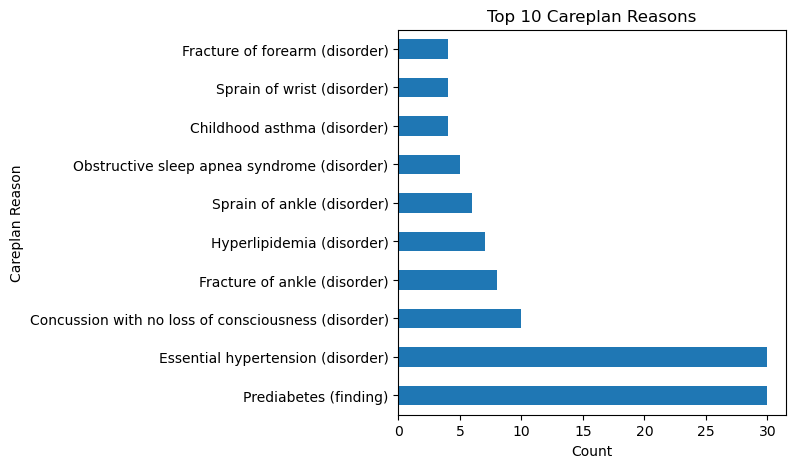

In [206]:
# Get and plot top careplan reasons
df = dfs['careplans']
df['REASONDESCRIPTION'].value_counts().sort_values(
    ascending=False).head(10).plot(kind='barh', 
                                   figsize=(5, 5),
                                   xlabel='Count',
                                   ylabel='Careplan Reason',
                                   title='Top 10 Careplan Reasons')

## Clean Data

In [207]:
df = dfs['patients']
# Reduce cols
cols = [
    'Id',
    'BIRTHDATE',
    'DEATHDATE',
    'MARITAL',
    'RACE',
    'ETHNICITY',
    'GENDER',
    'BIRTHPLACE',
    'CITY',
    'STATE',
    'COUNTY',
    'LAT',
    'LON',
    'HEALTHCARE_EXPENSES',
    'HEALTHCARE_COVERAGE',
    'INCOME'
 ]
df = df[cols]
dfs['patients'] = df
print(dfs['patients'].shape)
dfs['patients'].head()

(106, 16)


,Id,BIRTHDATE,DEATHDATE,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,CITY,STATE,COUNTY,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,30a6452c-4297-a1ac-977a-6a23237c7b46,1994-02-06,NaN,M,white,nonhispanic,M,Boston Massachusetts US,Braintree,Massachusetts,Norfolk County,42.211142,-71.045802,56904.96,18019.99,100511
1,34a4dcc4-35fb-6ad5-ab98-be285c586a4f,1968-08-06,2009-12-11,D,white,nonhispanic,M,Chicopee Massachusetts US,Braintree,Massachusetts,Norfolk County,42.255420,-70.971016,124024.12,1075.06,49737
2,7179458e-d6e3-c723-2530-d4acfe1c2668,2008-12-21,NaN,NaN,white,nonhispanic,M,Spencer Massachusetts US,Mattapoisett,Massachusetts,Plymouth County,41.648292,-70.850619,45645.06,6154.94,133816
3,37c177ea-4398-fb7a-29fa-70eb3d673876,1994-01-27,NaN,M,asian,nonhispanic,F,Franklin Massachusetts US,Wareham,Massachusetts,Plymouth County,41.789096,-70.711616,12895.15,659951.61,17382
4,0fef2411-21f0-a269-82fb-c42b55471405,2019-07-27,NaN,NaN,white,nonhispanic,M,Brockton Massachusetts US,Groveland,Massachusetts,Essex County,42.734183,-70.976410,18500.02,5493.57,52159


In [208]:
df = dfs['observations']
# Reduce cols
df = df[['PATIENT', 'DATE', 'CATEGORY', 'DESCRIPTION', 'VALUE', 'UNITS']]
dfs['observations'] = df

# # Keep last observation per patient
# dfs['observations'] = dfs['observations'].sort_values(
#     by=['PATIENT', 'DATE'], ascending=[True, True]
# ).drop_duplicates(subset=['PATIENT'], keep='last')
# dfs['observations'] = dfs['observations'].drop(columns=['DATE'])

dfs['observations'] = dfs['observations'].rename(
    columns={
        'DATE': 'ObservationDate',
        'CATEGORY': 'ObservationCategory',
        'DESCRIPTION': 'ObservationDescription',
        'VALUE': 'ObservationValue',
        'UNITS': 'ObservationUnits'
    }
)
print(dfs['observations'].shape)
dfs['observations'].head()

(86360, 6)


,PATIENT,ObservationDate,ObservationCategory,ObservationDescription,ObservationValue,ObservationUnits
0,30a6452c-4297-a1ac-977a-6a23237c7b46,2016-04-10T09:04:48Z,vital-signs,Body Height,176.1,cm
1,30a6452c-4297-a1ac-977a-6a23237c7b46,2016-04-10T09:04:48Z,vital-signs,Pain severity - 0-10 verbal numeric rating [Sc...,3.0,{score}
2,30a6452c-4297-a1ac-977a-6a23237c7b46,2016-04-10T09:04:48Z,vital-signs,Body Weight,86.4,kg
3,30a6452c-4297-a1ac-977a-6a23237c7b46,2016-04-10T09:04:48Z,vital-signs,Body mass index (BMI) [Ratio],27.9,kg/m2
4,30a6452c-4297-a1ac-977a-6a23237c7b46,2016-04-10T09:04:48Z,vital-signs,Diastolic Blood Pressure,94.0,mm[Hg]


In [209]:
df = dfs['conditions']
# Reduce cols
df = df[['PATIENT', 'START', 'DESCRIPTION']]
dfs['conditions'] = df

# # Keep last condition per patient
# dfs['conditions'] = dfs['conditions'].sort_values(
#     by=['PATIENT', 'START'], ascending=[True, True]
# ).drop_duplicates(subset=['PATIENT'], keep='last')
# dfs['conditions'] = dfs['conditions'].drop(columns=['START'])

dfs['conditions'] = dfs['conditions'].rename(
    columns={'DESCRIPTION': 'CONDITION',
             'START': 'ConditionStartDate'})
print(dfs['conditions'].shape)
dfs['conditions'].head()

(3876, 3)


,PATIENT,ConditionStartDate,CONDITION
0,30a6452c-4297-a1ac-977a-6a23237c7b46,2012-04-01,Housing unsatisfactory (finding)
1,30a6452c-4297-a1ac-977a-6a23237c7b46,2012-04-01,Received higher education (finding)
2,30a6452c-4297-a1ac-977a-6a23237c7b46,2012-04-01,Transport problem (finding)
3,30a6452c-4297-a1ac-977a-6a23237c7b46,2012-04-01,Social isolation (finding)
4,30a6452c-4297-a1ac-977a-6a23237c7b46,2012-04-01,Stress (finding)


In [210]:
df = dfs['careplans']
# Reduce cols
df = df[['PATIENT', 'START', 'REASONDESCRIPTION']]
dfs['careplans'] = df
# Keep last careplan per patient
dfs['careplans'] = dfs['careplans'].sort_values(
    by=['PATIENT', 'START'], ascending=[True, True]
).drop_duplicates(subset=['PATIENT'], keep='last')
print(dfs['careplans'].shape)
# Fill NA values
dfs['careplans']['REASONDESCRIPTION'] = dfs['careplans']['REASONDESCRIPTION'].fillna('NA')
# Create binary column for prediabetes
dfs['careplans']['PREDIABETES'] = dfs['careplans']['REASONDESCRIPTION'].apply(
    lambda x: 1 if 'prediabetes' in x.lower() else 0
)
dfs['careplans'] = dfs['careplans'].drop(columns=['REASONDESCRIPTION']) 
dfs['careplans'] = dfs['careplans'].rename(
    columns={'START': 'PREDIABETES_START'})
dfs['careplans'].head()

(100, 3)


,PATIENT,PREDIABETES_START,PREDIABETES
37,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0
222,03bde354-de87-a404-4ab3-00edf0b184a7,2018-12-08,0
54,0689b59f-0721-5384-9294-def3c13db427,2017-02-08,0
109,081abe99-9641-1098-8903-61de9e66d9fa,2023-06-25,0
280,0bc53e6a-8820-ded4-57c5-7ccc6355354c,2019-09-17,0


## Merge Data

In [211]:
final_df = dfs['careplans'].copy()
final_df = final_df.merge(
    dfs['patients'],
    left_on='PATIENT',
    right_on='Id',
    how='inner'
)
final_df = final_df.merge(
    dfs['observations'],
    left_on='PATIENT',
    right_on='PATIENT',
    how='inner'
)
final_df = final_df.merge(
    dfs['conditions'],
    left_on='PATIENT',
    right_on='PATIENT',
    how='inner'
)
final_df = final_df.drop(columns=['Id'])
print(final_df.shape)
final_df.head()

(9349775, 25)


,PATIENT,PREDIABETES_START,PREDIABETES,BIRTHDATE,DEATHDATE,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,...,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,ObservationDate,ObservationCategory,ObservationDescription,ObservationValue,ObservationUnits,ConditionStartDate,CONDITION
0,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0,1975-12-24,NaN,W,white,nonhispanic,M,Toulouse Occitanie FR,...,235654.66,753044.17,30550,2015-06-24T14:05:28Z,laboratory,Hemoglobin A1c/Hemoglobin.total in Blood,3.3,%,1993-02-10,Risk activity involvement (finding)
1,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0,1975-12-24,NaN,W,white,nonhispanic,M,Toulouse Occitanie FR,...,235654.66,753044.17,30550,2015-06-24T14:05:28Z,laboratory,Hemoglobin A1c/Hemoglobin.total in Blood,3.3,%,1994-02-16,Housing unsatisfactory (finding)
2,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0,1975-12-24,NaN,W,white,nonhispanic,M,Toulouse Occitanie FR,...,235654.66,753044.17,30550,2015-06-24T14:05:28Z,laboratory,Hemoglobin A1c/Hemoglobin.total in Blood,3.3,%,1994-02-16,Received higher education (finding)
3,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0,1975-12-24,NaN,W,white,nonhispanic,M,Toulouse Occitanie FR,...,235654.66,753044.17,30550,2015-06-24T14:05:28Z,laboratory,Hemoglobin A1c/Hemoglobin.total in Blood,3.3,%,1998-02-25,Essential hypertension (disorder)
4,00732e11-5e4d-37b7-01f8-929a25536862,2023-12-20,0,1975-12-24,NaN,W,white,nonhispanic,M,Toulouse Occitanie FR,...,235654.66,753044.17,30550,2015-06-24T14:05:28Z,laboratory,Hemoglobin A1c/Hemoglobin.total in Blood,3.3,%,1998-02-25,Has a criminal record (finding)


In [212]:
list(final_df)

['PATIENT',
 'PREDIABETES_START',
 'PREDIABETES',
 'BIRTHDATE',
 'DEATHDATE',
 'MARITAL',
 'RACE',
 'ETHNICITY',
 'GENDER',
 'BIRTHPLACE',
 'CITY',
 'STATE',
 'COUNTY',
 'LAT',
 'LON',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE',
 'INCOME',
 'ObservationDate',
 'ObservationCategory',
 'ObservationDescription',
 'ObservationValue',
 'ObservationUnits',
 'ConditionStartDate',
 'CONDITION']

In [215]:
final_df.loc[final_df['PREDIABETES'] == 1].sample(10, random_state=55)

,PATIENT,PREDIABETES_START,PREDIABETES,BIRTHDATE,DEATHDATE,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,...,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,ObservationDate,ObservationCategory,ObservationDescription,ObservationValue,ObservationUnits,ConditionStartDate,CONDITION
7635194,f339a5f7-0b09-3072-2b01-7c8e8ca2c1fc,2014-07-17,1,1951-11-22,NaN,S,asian,nonhispanic,F,Millis-Clicquot Massachusetts US,...,655129.70,381212.81,92537,2020-08-20T10:04:44Z,survey,At any point in the past 2 years has season o...,No,NaN,2018-04-04,Injury of neck (disorder)
4592690,c1ce8dfc-3c0d-de97-ce0e-5dc0460da340,2023-09-11,1,1997-05-12,NaN,NaN,black,nonhispanic,M,Boston Massachusetts US,...,13354.75,290590.06,20158,2021-05-12T18:09:04Z,NaN,QOLS,1.0,{score},2019-07-29,Acute bronchitis (disorder)
4585379,c1ce8dfc-3c0d-de97-ce0e-5dc0460da340,2023-09-11,1,1997-05-12,NaN,NaN,black,nonhispanic,M,Boston Massachusetts US,...,13354.75,290590.06,20158,2021-08-30T18:48:32Z,survey,Are you worried about losing your housing?,No,NaN,2016-07-18,Medication review due (situation)
4574550,c1ce8dfc-3c0d-de97-ce0e-5dc0460da340,2023-09-11,1,1997-05-12,NaN,NaN,black,nonhispanic,M,Boston Massachusetts US,...,13354.75,290590.06,20158,2016-07-18T18:09:04Z,vital-signs,Body Weight,81.5,kg,2015-07-13,Serving in military service (finding)
534984,30a6452c-4297-a1ac-977a-6a23237c7b46,2022-04-17,1,1994-02-06,NaN,M,white,nonhispanic,M,Boston Massachusetts US,...,56904.96,18019.99,100511,2022-04-17T09:04:48Z,laboratory,Carbon dioxide total [Moles/volume] in Blood,22.0,mmol/L,2022-04-17,Prediabetes (finding)
7633358,f339a5f7-0b09-3072-2b01-7c8e8ca2c1fc,2014-07-17,1,1951-11-22,NaN,S,asian,nonhispanic,F,Millis-Clicquot Massachusetts US,...,655129.70,381212.81,92537,2019-08-15T10:23:15Z,survey,Fall risk total [Morse Fall Scale],61.0,{#},2020-08-20,Victim of intimate partner abuse (finding)
4575512,c1ce8dfc-3c0d-de97-ce0e-5dc0460da340,2023-09-11,1,1997-05-12,NaN,NaN,black,nonhispanic,M,Boston Massachusetts US,...,13354.75,290590.06,20158,2016-07-18T19:00:44Z,survey,How many people are living or staying at this ...,7.0,{#},2019-08-19,Medication review due (situation)
7633394,f339a5f7-0b09-3072-2b01-7c8e8ca2c1fc,2014-07-17,1,1951-11-22,NaN,S,asian,nonhispanic,F,Millis-Clicquot Massachusetts US,...,655129.70,381212.81,92537,2019-08-15T10:23:15Z,survey,Fall risk level [Morse Fall Scale],High Risk (MFS Score 50+),NaN,2018-04-04,Injury of neck (disorder)
533770,30a6452c-4297-a1ac-977a-6a23237c7b46,2022-04-17,1,1994-02-06,NaN,M,white,nonhispanic,M,Boston Massachusetts US,...,56904.96,18019.99,100511,2016-04-10T10:22:03Z,survey,Generalized anxiety disorder 7 item (GAD-7) to...,3.0,{score},2020-10-30,Sprain (morphologic abnormality)
4584743,c1ce8dfc-3c0d-de97-ce0e-5dc0460da340,2023-09-11,1,1997-05-12,NaN,NaN,black,nonhispanic,M,Boston Massachusetts US,...,13354.75,290590.06,20158,2021-08-30T18:09:04Z,vital-signs,Heart rate,68.0,/min,2021-04-19,Gingivitis (disorder)


---

## Prompt Engineering

In [216]:
prompt = """
    Decide in a single word if the
    patient requires a prediabetes care plan given the patient has Body Weight over 80 kg.
    Does this patient require a prediabetes care plan or not?
"""
messages = [
    {"role": "user", 
    "content": prompt}
    ]
input_text=tokenizer.apply_chat_template(messages, tokenize=False)
inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)
outputs = model.generate(
    inputs, 
    max_new_tokens=50, 
    temperature=0.2, 
    top_p=0.9, 
    do_sample=True)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

system
You are a helpful AI assistant named SmolLM, trained by Hugging Face
user

    Decide in a single word if the
    patient requires a prediabetes care plan given the patient has Body Weight over 80 kg.
    Does this patient require a prediabetes care plan or not?

assistant
No


In [ ]:
messages = [
    {"role": "system",
    "content": "You are a helpful assistant."},
    {"role": "user", 
    "content": "What is the capital of France."}
    ]
input_text=tokenizer.apply_chat_template(messages, tokenize=False)
inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)
outputs = model.generate(
    inputs, 
    max_new_tokens=50, 
    temperature=0.2, 
    top_p=0.9, 
    do_sample=True)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

system
You are a helpful assistant.
user
What is the capital of France.
assistant
The capital of France is Paris.


In [ ]:
messages = [
    {"role": "system",
    "content": "You are a helpful assistant."},
    {"role": "user", 
    "content": "What is the capital of France."}
    ]
input_text=tokenizer.apply_chat_template(messages, tokenize=False)
inputs = tokenizer.encode(input_text, return_tensors="pt").to(device)
outputs = model.generate(
    inputs, 
    max_new_tokens=50, 
    temperature=0.2, 
    top_p=0.9, 
    do_sample=True)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

system
You are a helpful assistant.
user
What is the capital of France.
assistant
The capital of France is Paris.
